<h1 style="color: orange; font-size: 40px; font-weight: bold;">
LAB 10
</h1>

<h2 style="color: green; font-size: 35px; font-weight: bold;">
Parallel Computing with MPI
</h2>

In [7]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import numpy as np

shapefile_path = "natural_earth_data/ne_110m_admin_0_countries.shp"
world = gpd.read_file(shapefile_path)
italy_map = world[world["NAME"] == "Italy"]

data_cap_coord = np.loadtxt("./PARALLEL_TEMP/INPUT/cap_prov_ita.dat")
x_c = data_cap_coord[: , 0]
y_c = data_cap_coord[: , 1]
labels_c=np.arange(len(x_c))

def plot_TSP_Italy(ax, X_c, Y_c, X_path, Y_path, labels_c, best_loss, title_suffix=""):

    italy_map.plot(ax=ax, color='white', edgecolor='black', zorder=1)

    ax.plot(X_path, Y_path, 'b-o', linewidth=2, markersize=6, label='Best path', zorder=2)
    ax.scatter(X_c, Y_c, color='r', s=50, zorder=3, label='Cities')
    ax.plot(X_c[0], Y_c[0], color='green', ls='none', marker='o', zorder=4, markersize=10, markeredgecolor='black', label='Start/End city')
    for i, label in enumerate(labels_c):
        ax.text(X_c[i], Y_c[i], str(label), fontsize=10, ha="right", va="bottom", zorder=5,)

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend()

    loss_val = best_loss[-1, 1]
    ax.set_title(f"TSP 110 Italian Capitals {title_suffix}, loss = {loss_val:.2f}")
    

def an_accept(folder_path):
    all_data = []

    if not os.path.exists(folder_path):
        print(f"Errore: La cartella '{folder_path}' non esiste!")
        return None

    for filename in os.listdir(folder_path):
        if filename.startswith("acceptance_rank_") and filename.endswith(".dat"):
            name_without_ext = filename.replace(".dat", "")
            my_rank = int(name_without_ext.split("_")[-1])
            file_path = os.path.join(folder_path, filename)

            try:
                df_rank = pd.read_csv(
                    file_path, sep=r"\s+", comment="#", header=None
                )
                df_rank.columns = ["BLOCK", "PARTNER", "MY_BETA", "PART_BETA",
                                   "DELTA_BETA", "DELTA_COST", "ACCEPTED",]
                df_rank["MY_RANK"] = my_rank
                all_data.append(df_rank)
            except Exception as e:
                print(f"Errore nella lettura di {filename}: {e}")

    if not all_data:
        print(f"Nessun file valido trovato in: {folder_path}")
        return None

    df_all = pd.concat(all_data, ignore_index=True)

    df_all["coppia"] = df_all.apply(
        lambda r: f"{min(int(r['MY_RANK']), int(r['PARTNER']))}-{max(int(r['MY_RANK']), int(r['PARTNER']))}",
        axis=1,
    )

    report = (
        df_all.groupby("coppia")["ACCEPTED"].agg(["mean", "count"]).reset_index()
    )
    report.columns = ["Scambio", "Accettazione Media", "Totale Tentativi"]

    report["sort_key"] = report["Scambio"].apply(
        lambda x: int(x.split("-")[0])
    )
    report = report.sort_values("sort_key").reset_index(drop=True)

    for _, row in report.iterrows():
        print(
            f"Couple {row['Scambio']:<6} | Acceptation: {row['Accettazione Media']:>6.2%}"
        )
    print("=" * 35)

def plot_beta(ax, size, beta_max, beta_min, title, _beta=np.array([])):
    rank = np.arange(size)
    if len(_beta)==0:
        _beta = beta_max + (beta_min - beta_max) * (1.0 - rank / (size -1))**2.5;
    ax.scatter(rank, _beta, color='r', alpha=0.7)
    for i in range(len(rank)-1):
        ax.vlines(rank[i+1], _beta[i+1], _beta[i], colors='g', ls='--')
        ax.text(rank[i+1]+0.05, (_beta[i]+_beta[i+1]) / 2, f"{_beta[i+1]-_beta[i]:.2f}", fontsize=9, va='center')
    ax.set_xlabel("Rank")
    ax.set_ylabel(r"$\beta(Rank)$")
    ax.set_title(title)
    #ax.legend()
    ax.grid(True)

def plot_losses(ax, folder, size, title="Rank's loss during optimization"):
    for rank in range(size):
        data = np.loadtxt(f"{folder}/Cost_values_cap_prov_ita_{rank}.dat")#(f"./OUTPUT/Cost_values_cap_prov_ita_{rank}.dat", usecols=(0, 1))#
        step = data[:, 0]
        values = data[:, 1]
        ax.plot(step, values, label=f"Rank {rank}", alpha=0.7)
        
    ax.set_title(title)
    ax.set_xlabel("Generation")
    ax.set_ylabel("L")
    ax.grid()
    ax.legend()

<p style="color: blue; font-size: 25px; font-weight: bold;">
Parallel Programming
</p>

This notebook aims to analyze and quantify the computational benefits derived from the parallelization of code applied to stochastic optimization problems. The analysis focuses on evaluating improvements in both temporal performance and the intrinsic quality of the solution.

The particular instance addressed requires finding the minimum-distance path connecting Italian provincial capitals.

The concept of parallel programming is central to scientific research, particularly in the realm of numerical simulations and complex computational problems. The computational power required for many large-scale tasks often exceeds the capabilities of standard, serially-executing processors. The most viable way to achieve further increases in computational performance is through parallelization. This paradigm involves decomposing a large task (operations) into smaller sub-tasks, which are then distributed among multiple computing agents (processors or cores).

Parallelization and communication among the distinct processes in this study is managed using the **OpenMPI** library, an implementation of the **Message Passing Interface (MPI)** standard. MPI defines an Application Programming Interface (API) for inter-process communication, which is intrinsically tied to the Distributed Memory Architecture model.

<p style="color: blue; font-size: 25px; font-weight: bold;">
Parallel tempering
</p>

Parallel tempering is an optimization technique which combine simulated annealing procedure with communications.

Low temperature simulations can be trapped for long times in similar metastable configurations because the energy barriers to competing different
configurations can be very high. In parallel tempering we consider n systems setted at different temperature, and in each of these systems we perform a simulation in the canonical ensemble.

Systems with a sufficiently high temperature pass over the potential and can explore the confirational space.
The low-temperature systems, on the other hand, mainly probe the local energy minima. The idea of parallel tempering is to include MC trial moves that attempt to "swap" systems that belong to different thermodynamic states.

If the temperature difference between the two systems is very large,
such a swap has a very low probability of being accepted instead of
making attempts to swap between a low and a high temperature, we
swap between ensembles with a small temperature difference.

We can also introduce a Monte Carlo move, which consists of a swap between two
ensembles. The acceptance rule of a swap between ensembles i and j follows from the condition of detailed balance and lead to a Metropolis criterion
$$
P=\min\bigg[1, e^{\Delta\beta\Delta L}\bigg],
$$
where $\Delta\beta=\beta _i -\beta _j$ and $\Delta L = L(\mathbf{x}_i) - L(\mathbf{x} _j)$. So, in principle $\Delta\beta<0$ for the rank at lower temperature, and the swap is higly probable to be accepted if the Loss function is lower (really convenient P=1), otherwise it will be accepted with $e^{\Delta\beta\Delta L}$. On the other hand, for the system at higher temperature $\Delta\beta>0$, and so if its Loss is lower than the partner one, the swap will be accepted (P=1), otherwise with the same probability as before. This symmetry allow us to make the lower temperature rank to choose if the move is accepted or not.

Applied as an optimization technique, the node with lowest temperature will typically yield the estimate for the global optimum, while all others are required to generate different configurations.

<p style="color: red; font-size: 25px; font-weight: bold;">
Settings
</p>

There are several parameters that need to be set in order to achieve optimal performance of the algorithm. The simulation is performed with 11 MPI prcesses.

# Temperature range
First, we need to define a temperature interval that allows both an efficient exploration of the configurational space and an accurate resolution of local minima. This range depends on the number of ranks used and on the differences in $\beta$ between adjacent ranks. After several tests, we selected the following temperature interval:
$$
T\in[0.1,\ 1.4].
$$
This interval provides a good compromise between exploration capabilities and a suitable spacing in $\beta$ among ranks. The temperature assigned to each rank is determined via a geometric-like progression:
$$
\beta(rank) = \beta _{start} + (\beta _{end}-\beta _{start})\bigg(1-\frac{rank}{size-1}\bigg)^{2.5},
$$
where `size` is the number of rank used, $\beta _{start}=\frac{1}{1.4}$ and $\beta _{end}=\frac{1}{0.1}$.
The simulations performed using this temperature distribution resulted in an inefficient exchange acceptance rate between processes, as shown in the following plot.

To improve this behavior, we manually adjusted the $\beta$ distribution by bringing closer the values associated with neighboring ranks. In this way, even when the loss difference between two specific ranks is relatively large, the exchange can still be accepted with a reasonable probability. In particular, to obtain the minimum value of $\Delta\beta$ between ranks, we imposed an acceptance probability of $P=0.2$ for the largest observed $\Delta L$.

The resulting $\beta$ distribution is:
$$
[10, 7.84974, 5.63345, 3.95345, 2.73345, 1.88345, 1.33345, 1.13349, 0.96394, 0.82365, 0.714286]
$$

Acceptation analysis - Pure geometric-like
Couple 0-1    | Acceptation: 10.00%
Couple 1-2    | Acceptation: 14.00%
Couple 2-3    | Acceptation: 12.00%
Couple 3-4    | Acceptation:  8.00%
Couple 4-5    | Acceptation:  6.00%
Couple 5-6    | Acceptation:  2.00%
Couple 6-7    | Acceptation:  0.00%
Couple 7-8    | Acceptation:  0.00%
Couple 8-9    | Acceptation: 16.00%
Couple 9-10   | Acceptation: 78.00%
Acceptation analysis - Manual
Couple 0-1    | Acceptation: 12.00%
Couple 1-2    | Acceptation: 14.00%
Couple 2-3    | Acceptation: 12.00%
Couple 3-4    | Acceptation: 10.00%
Couple 4-5    | Acceptation:  4.00%
Couple 5-6    | Acceptation:  6.00%
Couple 6-7    | Acceptation: 18.00%
Couple 7-8    | Acceptation: 20.00%
Couple 8-9    | Acceptation: 32.00%
Couple 9-10   | Acceptation: 26.00%


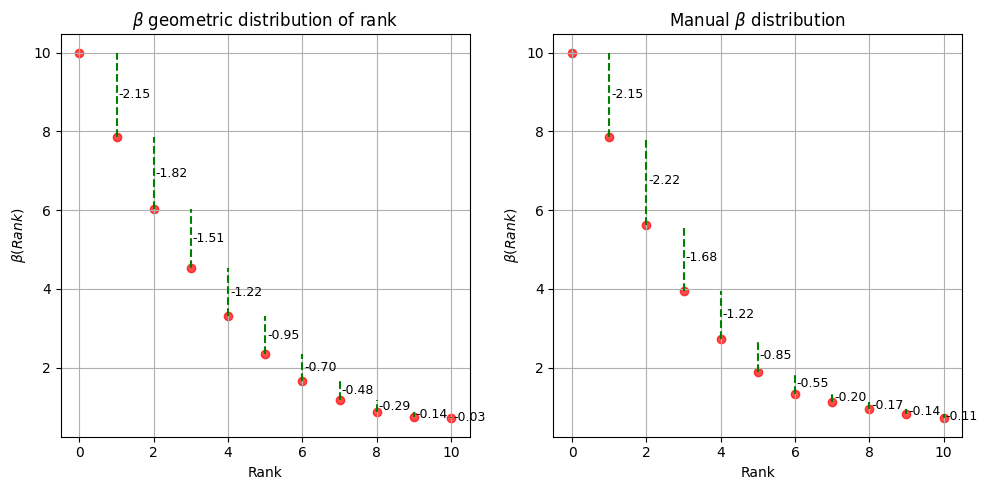

In [8]:
import numpy as np
import matplotlib.pyplot as plt

size = 11
_beta_max = 1 / 1.4
_beta_min = 1 / 0.1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

plot_beta(ax1, size, _beta_max, _beta_min, r"$\beta$ geometric distribution of rank")
print("=" * 42)
print("Acceptation analysis - Pure geometric-like")
print("=" * 42)
an_accept("./PARALLEL_TEMP/OUTPUT__pure_geometric")
_beta = np.array([10, 7.84974, 5.63345, 3.95345, 2.73345, 1.88345, 1.33345, 1.13349, 0.96394, 0.82365, 0.714286])
print("=" * 42)
print("Acceptation analysis - Manual")
print("=" * 42)
an_accept("./PARALLEL_TEMP/OUTPUT__")
plot_beta(ax2, size, _beta_max, _beta_min, r"Manual $\beta$ distribution", _beta)
plt.tight_layout()
plt.show()

# Mutation type and frequency

The other decision is to choose which mutation apply and in which order. One can expect that a random choice among mutation types naturally leads to stochastic variability. Moreover, the mutations have various degrees of complexitySome of them are simple and leave the sequence almost unchanged, such as the swap mutation (the simplest one), while others, such as shift, permutation and inversion are more complex and can significantly modify the sequence. Another way to increase stochastic variability is to apply multiple mutations within a single evolution step.

Again one may expect that great variability allow a more effective exploration of the configuration space. This is indeed true, to some extent, for the warmer ranks. The following plot shows this behavior, demonstrating that random selection, complex mutation and multiple mutations are not efficient in achieving this. The simpler the mutations are, the better the results are. 

To implement this, one can choose to only use simple swap as a move, or to choose the mutation type with an unfair roulette selecting the mutation type giving more probaility to the swap.


```cpp
for(int j=0; j<_N_mut; j++) mutation(int(4 * pow(_rnd.Rannyu(), 2.5)), parent);
```
where we use `N_mut=1` and the exponent 2.5 represent the best choice.

The following plots show the loss evolution of simulations performed with 7 ranks, using two different numbers of mutations per evolution step and different selections of mutation types. The temperature distribution and the number of steps per evolution are kept the same.

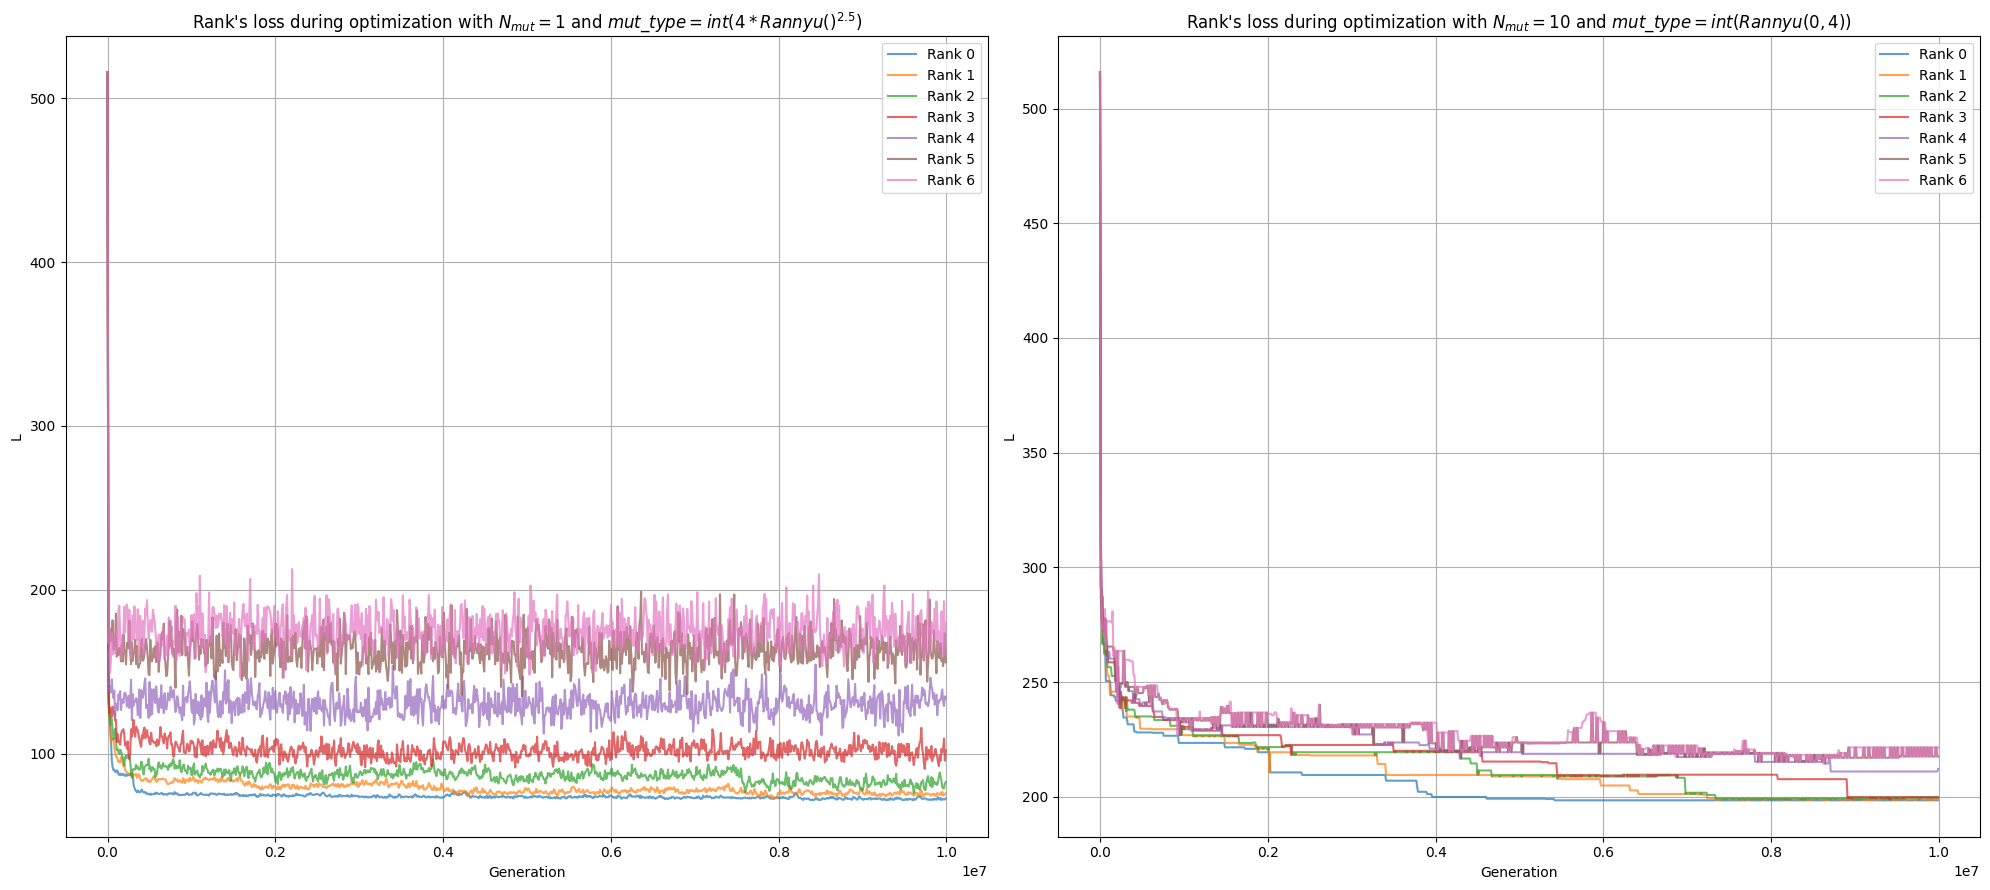

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9))
plot_losses(ax1, "./PARALLEL_TEMP/OUTPUT__SIMPLE", 7, r"Rank's loss during optimization with $N_{mut}=1$ and $mut\_type = int(4*Rannyu()^{2.5})$")
plot_losses(ax2, "./PARALLEL_TEMP/OUTPUT__complex", 7, r"Rank's loss during optimization with $N_{mut}=10$ and $mut\_type = int(Rannyu(0, 4))$")
plt.tight_layout()
plt.show()

<p style="color: blue; font-size: 25px; font-weight: bold;">
SIMULATION
</p>

The simulation is made with 11 rank, with the following parameters
```text
MAX_TEMPERATURE    1.4
MIN_TEMPERATURE    0.1
N_MIGR             1000
N_STEP_T_MAX       10000
TYPE               cap_prov_ita.dat
N_MUT_PER_EV       1

ENDINPUT

All processes currently use the same number of optimization steps (N_STEP_T_MAX). However, the code is already structured to allow a different number of steps to be assigned to each temperature. This feature is currently commented out, and the notation N_STEP_T_MAX has been retained to facilitate its future activation.

```
# Communication procedure
The communication between two neighboring ranks is handled by the swap function:
```cpp
void exchange(int rank, int partner, population& pop, int Ncities, ofstream& coutll, int genblock)
```
This function determines whether the migration should be accepted and, if so, with which probability, once the exchanging partner has been identified.

The partnership relation is defined by:
```cpp
void partnership(int rank, int size, int& part, int tag){
    if(tag==0){ // 0-1 / 2-3 / 4-5 / ...
        if(rank%2==0){ // Se sei pari il tu partner è il successivo
            part = (rank+1 < size) ? rank+1 : rank; // l'ultimo rimane accoppiato a se stesso e nel main salterà lo scambio
        }
        else part = rank-1;
    }
    else{ // 1-2 / 3-4 / ...
        if(rank==0) part = rank;
        else if(rank%2==1){ // Se sei dispari il tu partner è il successivo
            part = (rank+1 < size) ? rank+1 : rank;
        }
        else part = rank-1;
    }
}
```
This function establish the pairing relation via a tag, which is computed as $gen\_ block % 2$. By alternating the tag value between even and odd generation blocks, the pairing scheme is shifted at each step, allowing all neighboring ranks to communicate over time. This approach also allows the algorithm to be used with an odd number of ranks.

# Selection of the best solution
At the end of the optimization process, the algorithm identifies the rank containing the global minimum loss. In principle this rank should be the co
low temperature one.

The local check is performed through:
```cpp
double Loss = mypop.get_cost(0);
double global_min;
MPI_Allreduce(&Loss, &global_min, 1, MPI_DOUBLE, MPI_MIN, MPI_COMM_WORLD);    
int ho_min = (Loss==global_min) ? 1 : 0;
vector<int> who_have_min(size);
int selected = -1;
select_unique(rank, size, ho_min, who_have_min, selected);
if(rank==selected) mypop.Print_final_Path("../OUTPUT/Miglior_percorso_prov_ita_"+to_string(rank)+".xy", rank);
```
with:
```cpp
void select_unique(int rank, int size, int have_min, vector<int>& who_have_mini, int& select){
    MPI_Gather(&have_min, 1, MPI_INT, &who_have_mini[0], 1, MPI_INT, 0, MPI_COMM_WORLD);
    if(rank==0){
        for(int i=0; i<size; i++){
            if(who_have_mini[i]==1){
                select = i;
                break;
            }
        }
    }
    MPI_Bcast(&select, 1, MPI_INT, 0, MPI_COMM_WORLD);
}
```
This function guarantees that only one copy of the best solution is printed, even in the case of multiple ranks reaching the same minimum.

# Results
The execution time with this parmeters is **4.65993 min**.

The swap acceptation between rank is shown in the previous section.

The following plots show the best path found and the loss during the optimization process.

Best loss:  67.1318


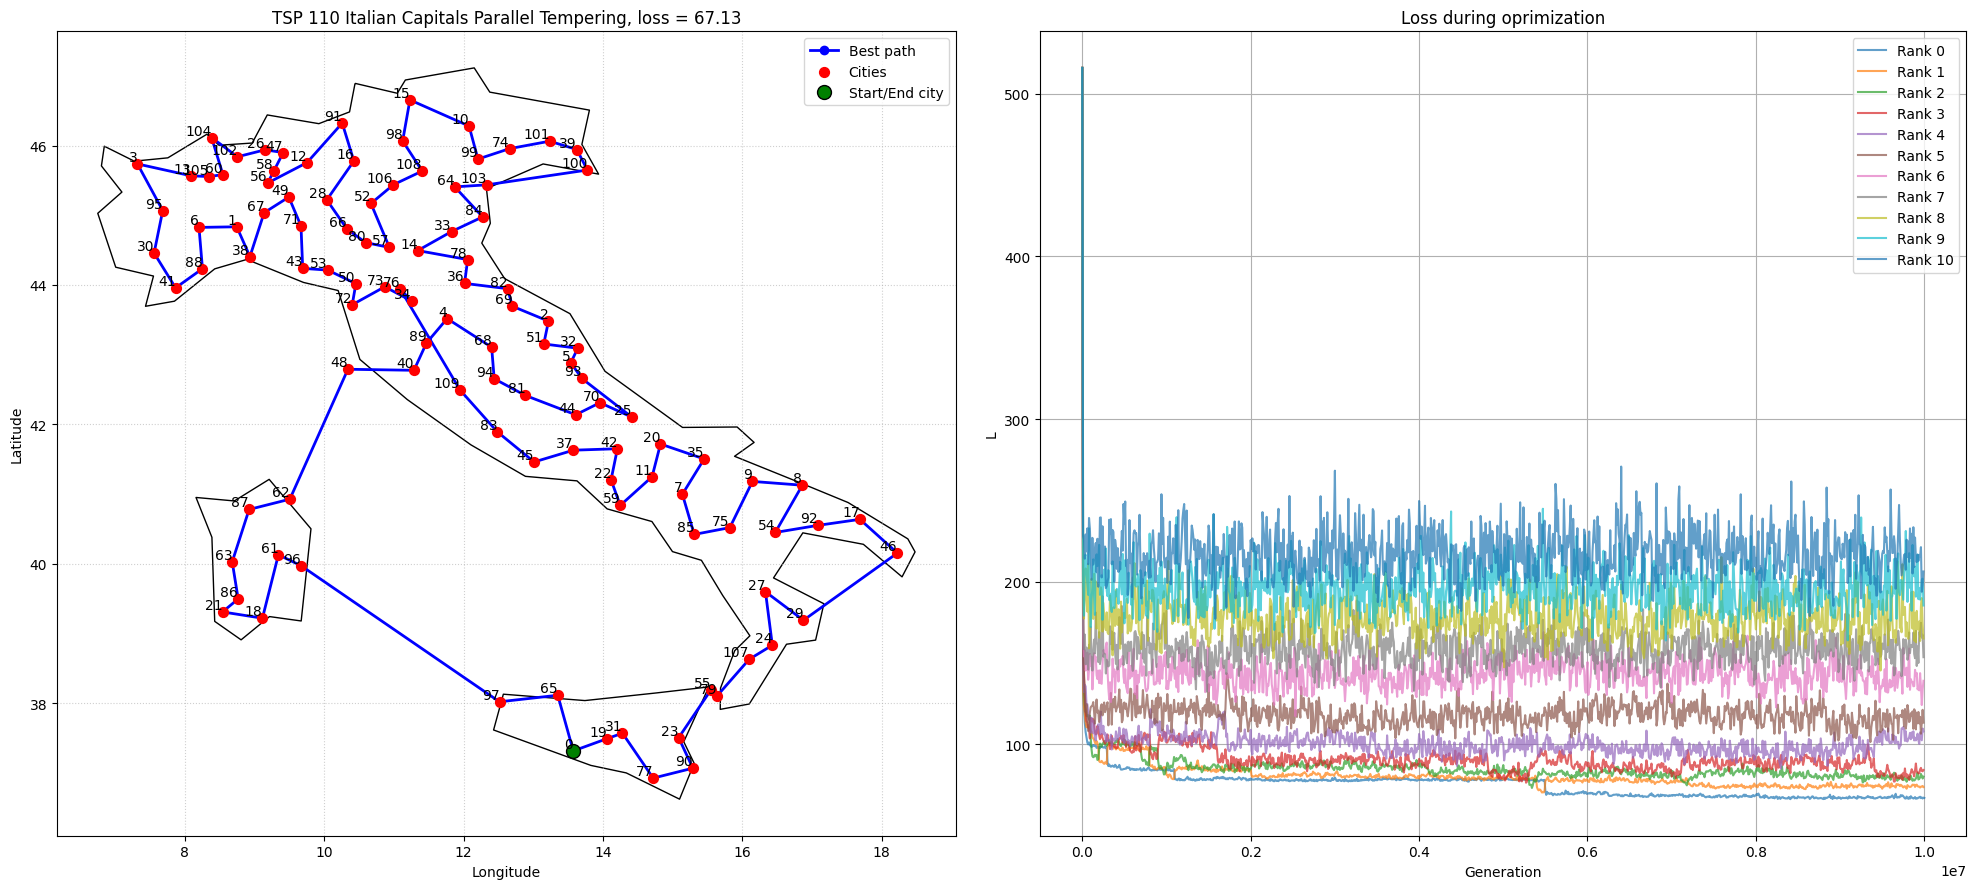

In [10]:
#load best path
best_path = np.loadtxt("./PARALLEL_TEMP/OUTPUT__/Miglior_percorso_prov_ita_0.xy")
best_loss = np.loadtxt("./PARALLEL_TEMP/OUTPUT__/Cost_values_cap_prov_ita_0.dat")
print("Best loss: ", best_loss[-1, 1])
#best_path_ind = best_path[:, 0].astype(int)
x_path = best_path[:, 1]#x_c[best_path_ind]
y_path = best_path[:, 2] #y_c[best_path_ind]

#add return
x_path = np.append(x_path, x_path[0])
y_path = np.append(y_path, y_path[0])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9))
plot_TSP_Italy(ax1, x_c, y_c, x_path, y_path, labels_c, best_loss, "Parallel Tempering")
plot_losses(ax2, "./PARALLEL_TEMP/OUTPUT__", 11, "Loss during oprimization")

plt.tight_layout()
plt.show()

<p style="color: blue; font-size: 25px; font-weight: bold;">
Parallel GA
</p>

Now we discuss an other possible solution of the TSP, this time made with a Genetic algortihm, the same of the Lecture 9, but it has been parallelized using MPI.

The code's structure is the same as Lecture 9, the difference is in the main:
- Each core ("continent") performs an independent GA search
- Every $N_{migr}$ generations, each continent picks up a random partner and exchanges the best Nmigrants indivuals with it

At the end, the master node gathers all the best paths found from the nodes and selects the best among them to be printed to the output file.

The `Population` class has undergone only minor changes compared to the previous exercise. These changes are mainly related to the limitations of the MPI interface when handling custom C++ objects. Therefore, a simpler approach is adopted by exchanging only `vector<int>` representations of the individuals.


During migration, processes exchange the gene sequences of their best individuals as integer vectors. The received vectors are then used by the method `population::substitute`, which replaces the genes of the worst individuals in the local population with the received ones, avoiding the creation of new chromosome instances.

# Implementation
The migration procedure is implemented according to the following scheme:
```cpp
int next_partner, prev_partner;
partnership(rank, size, mypop, migration, next_partner, prev_partner);
for(int l=0; l<n_migrants; l++){
    best_path = mypop.get_path(l).genes;
    // Sending messages
    MPI_Sendrecv(&best_path[0], N_cities, MPI_INT, next_partner, 0,
                 &recv_path[0], N_cities, MPI_INT, prev_partner, 0,
                 MPI_COMM_WORLD, MPI_STATUS_IGNORE);
    mypop.substitute(recv_path, N_individuals-l);
        }
```
The `MPI_Sendrecv` routine is used to perform the communication between processes while avoiding possible deadlocks that could occur with separate send and receive operations. The partnership relation is now defined on a mixed ring topology. In practice, an array containing the ordered ranks is randomly shuffled, and periodic boundary conditions (PBC) are applied so that the last element of the array communicates with the first one. Therefor, at each migration step, a different pairing between processes is generated, allowing the exchange of individuals among different populations over time. 

The main parameters to be tuned are the population size, the number of migration steps, the number of migrations, and the number of individuals exchanged during each migration. The number of genes per individual is fixed to 110, corresponding to the number of cities in the TSP problem.

The simulations are performed with
```text
N_CITIES         110
N_INDIVIDUALS    110000
N_EV_PER_MIGR    10
N_MIGR           40
N_MIGRANTS       4

ENDINPUT
```
After fixing these parameters, the probabilities associated with each mutation operator and with the crossover must be fixed. We use the same values adopted in Lecture 9, since they already provide good performance. Moreover, because each genetic evolution is performed independently by each process, the MPI parallelization does not require any modification of these algorithmic parameters.
```text
TYPE     cap_prov_ita.dat
P_SWAP   0.05
P_SHIFT  0.1
P_PERM   0.07
P_INV    0.1
P_CROSS  0.6
```

The computational time required by the algorithm to reach convergence is about **11.146 min**.

Best loss:  65.9877


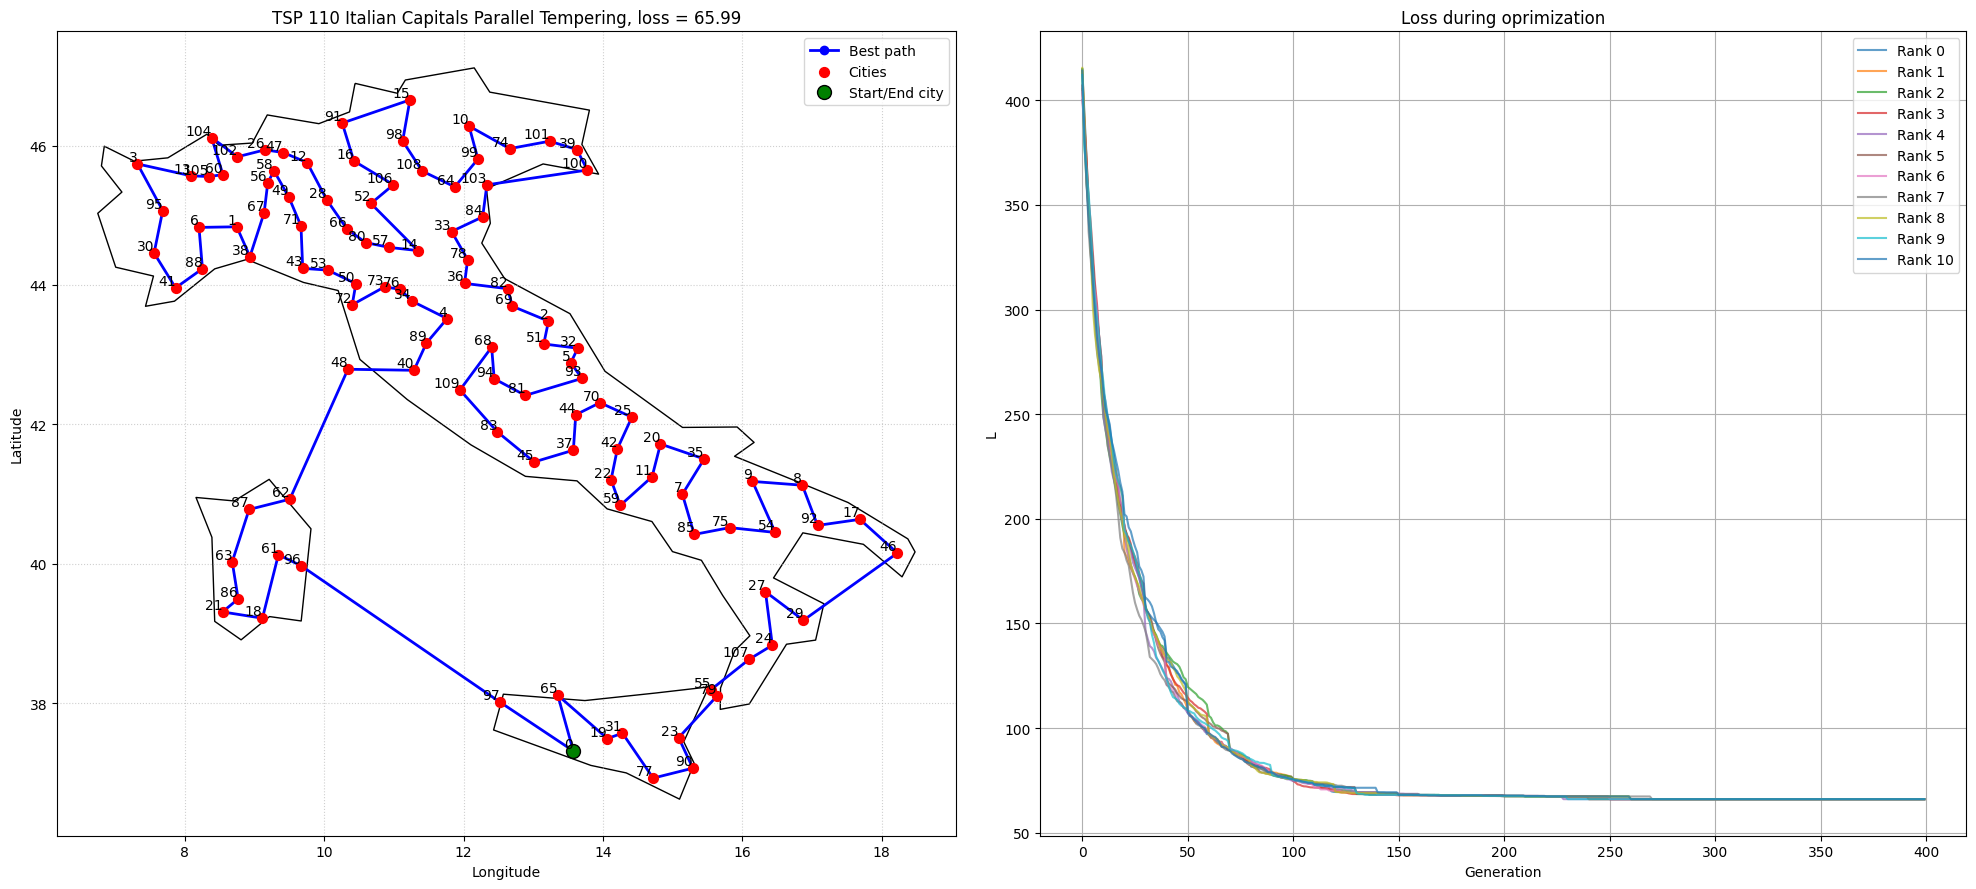

In [11]:
best_path = np.loadtxt("./PARALLEL_GA/OUTPUT/Miglior_percorso_prov_ita_0.xy")
best_loss = np.loadtxt("./PARALLEL_GA/OUTPUT/Cost_values_cap_prov_ita_0.dat")
print("Best loss: ", best_loss[-1, 1])
x_path = best_path[:, 1]
y_path = best_path[:, 2]

#add return
x_path = np.append(x_path, x_path[0])
y_path = np.append(y_path, y_path[0])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9))
plot_TSP_Italy(ax1, x_c, y_c, x_path, y_path, labels_c, best_loss, "Parallel Tempering")
plot_losses(ax2, "./PARALLEL_GA/OUTPUT", 11, "Loss during oprimization")

plt.tight_layout()
plt.show()

<p style="color: blue; font-size: 25px; font-weight: bold;">
Indipendent GA
</p>

We compare the two parallel implementations with a non-communicating genetic algorithm in order to assess the benefits of parallelization. 

The implementation is identical to the communicating version presented above, except that the migration step is disabled, while all the other input parameters and algorithm settings are kept unchanged. Each process evolves its local population independently for the entire simulation, and only the final best solutions are gathered by the master process.
This allows for a direct comparison of the effect of migration on the convergence of the algorithm.

```text
N_CITIES         110
N_INDIVIDUALS    110000
N_EV_PER_MIGR    10
N_MIGR           40
N_MIGRANTS       4

ENDINPUT
```

The computational time required by the algorithm to reach convergence is about **10.505 min**.

Best loss:  65.3274


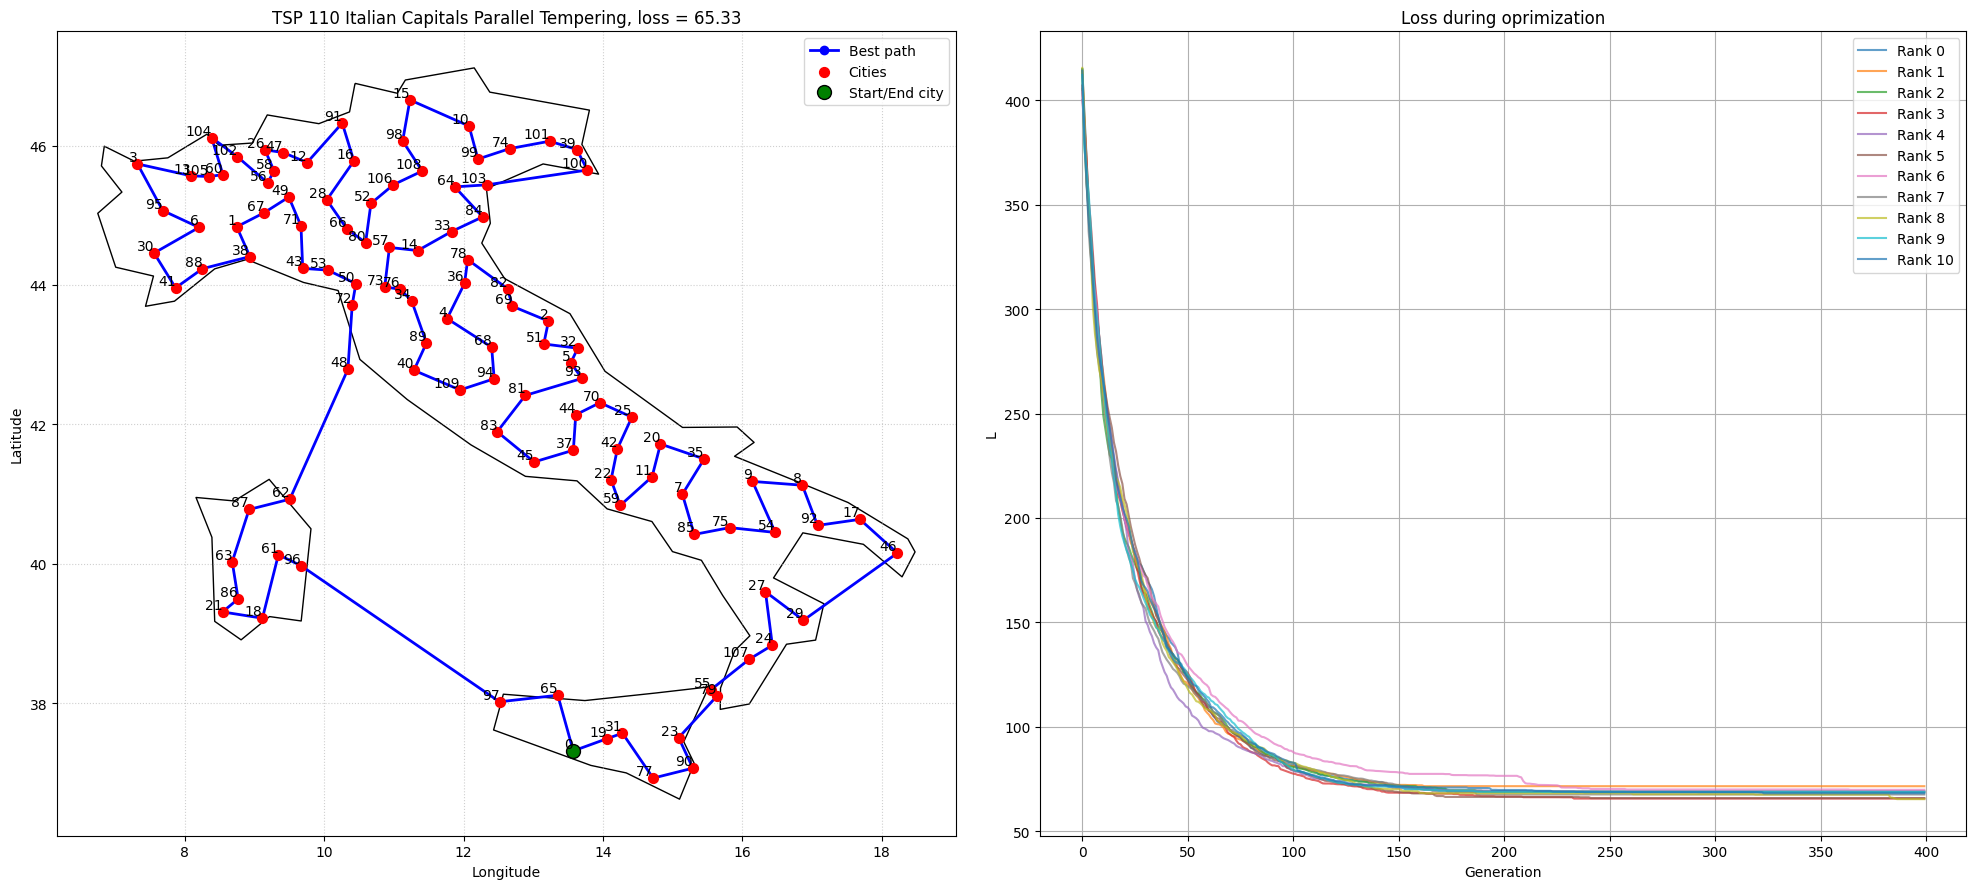

In [12]:
best_path = np.loadtxt("./NON_PARALLEL_GA/OUTPUT/Miglior_percorso_prov_ita_8.xy")
best_loss = np.loadtxt("./NON_PARALLEL_GA/OUTPUT/Cost_values_cap_prov_ita_8.dat")
print("Best loss: ", best_loss[-1, 1])
x_path = best_path[:, 1]
y_path = best_path[:, 2]

#add return
x_path = np.append(x_path, x_path[0])
y_path = np.append(y_path, y_path[0])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9))
plot_TSP_Italy(ax1, x_c, y_c, x_path, y_path, labels_c, best_loss, "Parallel Tempering")
plot_losses(ax2, "./NON_PARALLEL_GA/OUTPUT", 11, "Loss during oprimization")

plt.tight_layout()
plt.show()

<p style="color: green; font-size: 25px; font-weight: bold;">
Conclusions
</p>

We have presented three different methods for solving the NP-hard Traveling Salesman Problem (TSP) on 110 cities, Italian provincial capitals. All the algorithms considered converge to solutions of comparable quality, although the Parallel Tempering approach produces a slightly different final path.

The main result highlighted in this notebook is the quality of the final solutions. Both versions of the Genetic Algorithm, with and without communication between populations, achieve slightly better solutions than Parallel Tempering. Moreover, the comparison between the communicating the non-communicating versions, suggests that, for the present simulations, migrations do not significantly improve the final solution. In fact, both algorithms converge to essentially the same path, with only a difference of **0.633** in the loss function. The communicating version, however, requires additional inter-process communication, which slightly increases the overall execution time.

On the other hand, Parallel Tempering reaches a nearly equivalent solution in a significantly shorter computational time.

Further improvements to the Parallel Tempering algorithm, such as a more efficient or automated optimization of its hyperparameters, or the introduction of more diverse mutations in the replicas at higher temperatures, or simply the use of a larger number of processes (which was deliberately kept limited in this work to demonstrate that good results can be achieved even with modest computational resources), could potentially lead to solutions comparable to or even better than those obtained with the Genetic Algorithm.